In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose # Decomposition
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
import statsmodels.tsa.api as smt

%matplotlib inline

In [245]:
data = pd.read_csv('AirPassengers.csv')

In [246]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [247]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [248]:
data.columns = ['Month_year', 'Passengers']

In [249]:
data.columns

Index(['Month_year', 'Passengers'], dtype='object')

In [250]:
data.head()

,Month_year,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [251]:
data['Month_year'] = pd.to_datetime(data['Month_year'],format = '%Y-%m')

In [252]:
data.head()

,Month_year,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [253]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month_year  144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [254]:
data.set_index(data.Month_year, inplace= True)  

In [255]:
data

,Month_year,Passengers
Month_year,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121
...,...,...
1960-08-01,1960-08-01,606
1960-09-01,1960-09-01,508
1960-10-01,1960-10-01,461


In [256]:
data['Year'] = data.Month_year.dt.year
data['Month'] = data.Month_year.dt.month

In [257]:
data

,Month_year,Passengers,Year,Month
Month_year,,,,
1949-01-01,1949-01-01,112,1949,1
1949-02-01,1949-02-01,118,1949,2
1949-03-01,1949-03-01,132,1949,3
1949-04-01,1949-04-01,129,1949,4
1949-05-01,1949-05-01,121,1949,5
...,...,...,...,...
1960-08-01,1960-08-01,606,1960,8
1960-09-01,1960-09-01,508,1960,9
1960-10-01,1960-10-01,461,1960,10


<Axes: xlabel='Month_year'>

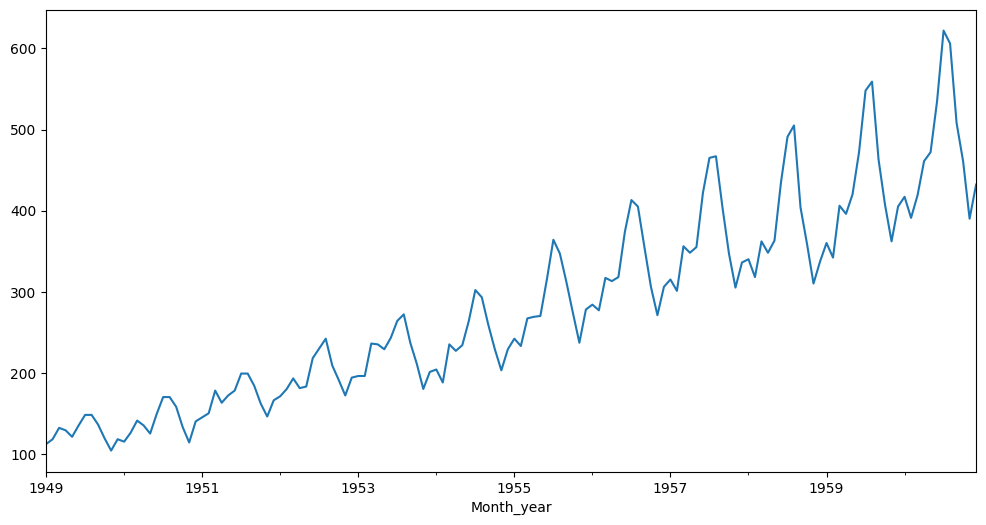

In [258]:
data.Passengers.plot(figsize=(12,6))

In [259]:
pd.pivot_table(data = data, index = 'Year', columns = 'Month', values = 'Passengers')

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
1949,112.0,118.0,132.0,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0
1950,115.0,126.0,141.0,135.0,125.0,149.0,170.0,170.0,158.0,133.0,114.0,140.0
1951,145.0,150.0,178.0,163.0,172.0,178.0,199.0,199.0,184.0,162.0,146.0,166.0
1952,171.0,180.0,193.0,181.0,183.0,218.0,230.0,242.0,209.0,191.0,172.0,194.0
1953,196.0,196.0,236.0,235.0,229.0,243.0,264.0,272.0,237.0,211.0,180.0,201.0
1954,204.0,188.0,235.0,227.0,234.0,264.0,302.0,293.0,259.0,229.0,203.0,229.0
1955,242.0,233.0,267.0,269.0,270.0,315.0,364.0,347.0,312.0,274.0,237.0,278.0
1956,284.0,277.0,317.0,313.0,318.0,374.0,413.0,405.0,355.0,306.0,271.0,306.0
1957,315.0,301.0,356.0,348.0,355.0,422.0,465.0,467.0,404.0,347.0,305.0,336.0


<Axes: xlabel='Year'>

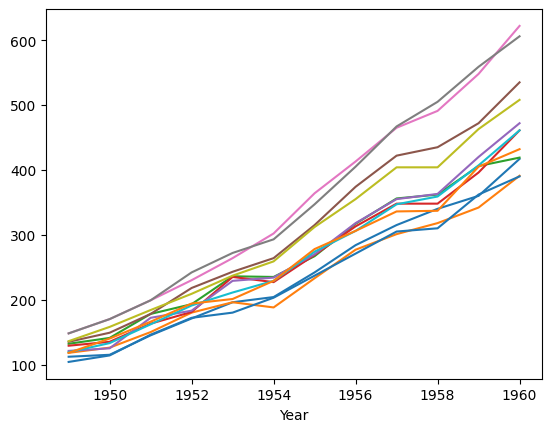

In [260]:
#Long to wide data
pd.pivot_table(data = data, index = 'Year', columns = 'Month', values = 'Passengers').plot(legend=False)

<Axes: xlabel='Month'>

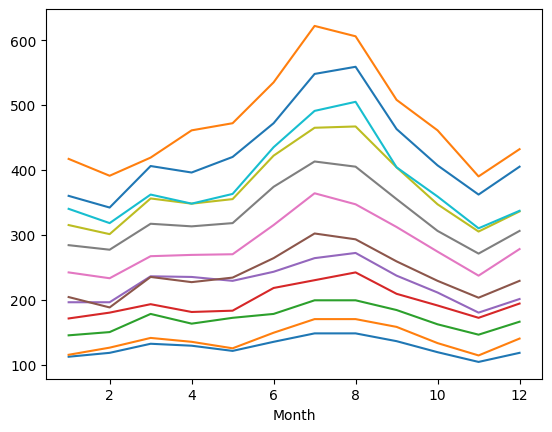

In [261]:
pd.pivot_table(data = data, index = 'Month', columns = 'Year', values = 'Passengers').plot(legend=False)

In [262]:
data.Passengers

Month_year
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, Length: 144, dtype: int64

In [263]:
tp = data.Passengers

In [264]:
tp

Month_year
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, Length: 144, dtype: int64

In [265]:
decom = seasonal_decompose(tp, model='multiplicative', period=12)

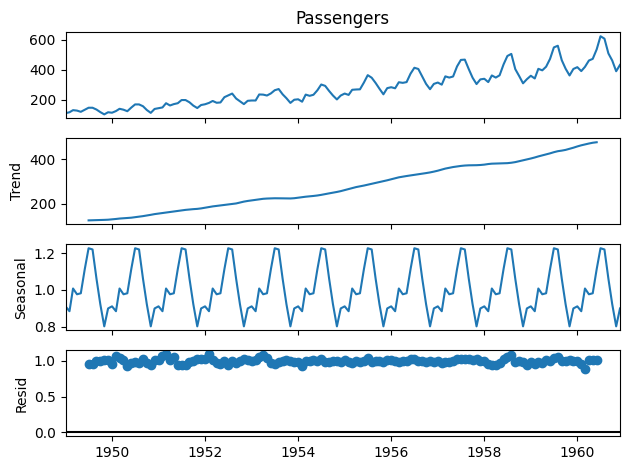

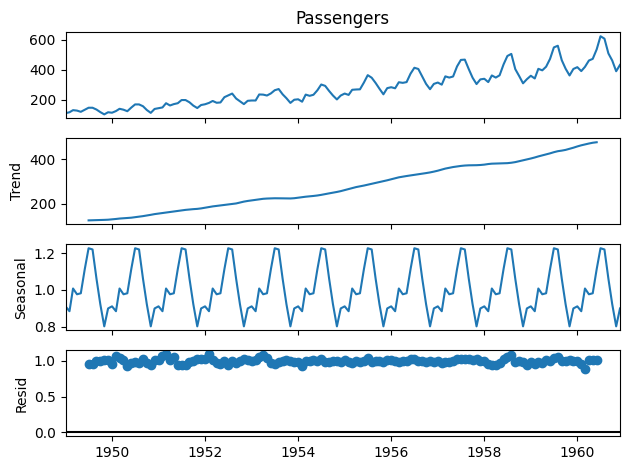

In [266]:
decom.plot()

In [267]:
decom.trend

Month_year
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: trend, Length: 144, dtype: float64

In [268]:
pd.concat([decom.observed, decom.trend, decom.seasonal, decom.resid], axis=1)

,Passengers,trend,seasonal,resid
Month_year,,,,
1949-01-01,112.0,NaN,0.910230,NaN
1949-02-01,118.0,NaN,0.883625,NaN
1949-03-01,132.0,NaN,1.007366,NaN
1949-04-01,129.0,NaN,0.975906,NaN
1949-05-01,121.0,NaN,0.981378,NaN
...,...,...,...,...
1960-08-01,606.0,NaN,1.219911,NaN
1960-09-01,508.0,NaN,1.060492,NaN
1960-10-01,461.0,NaN,0.921757,NaN


In [269]:

def auto_hwm(timeseries, val_split_date, alpha=[None], beta=[None], gamma=[None], 
              trend=None, seasonal=None, periods=None, verbose=False):

    best_params = []
    actual = timeseries[val_split_date:]

    print('Evaluating Exponential Smoothing model for', len(alpha) * len(beta) * len(gamma), 'fits\n')

    for a in alpha:
        for b in beta:
            for g in gamma:

                    if(verbose == True):
                        print('Checking for', {'alpha': a, 'beta': b, 'gamma': g})

                    model = ExponentialSmoothing(timeseries, trend=trend, seasonal=seasonal, seasonal_periods=periods)
                    model.fit(smoothing_level=a, smoothing_slope=b, smoothing_seasonal=g)
                    f_cast = model.predict(model.params, start=actual.index[0])
                    score = np.where(np.float64(mean_absolute_error(actual, f_cast)/actual).mean()>0,np.float64(mean_absolute_error(actual, f_cast)/actual).mean(),0)

                    best_params.append({'alpha': a, 'beta': b, 'gamma': g, 'mae': score})

    return min(best_params, key=lambda x: x['mae'])
    

In [270]:
alpha = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
beta = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
gamma =[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [271]:
tp['1960-07-01':]

Month_year
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, dtype: int64

In [272]:
auto_hwm(tp, val_split_date ='1960-07-01' , alpha=alpha, beta=beta, gamma=gamma, 
              trend='mul', seasonal='mul', periods=12, verbose=True)

Evaluating Exponential Smoothing model for 729 fits

Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.1}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.2}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.3}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.4}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.5}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.6}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.7}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.8}
Checking for {'alpha': 0.1, 'beta': 0.1, 'gamma': 0.9}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.1}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.2}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.3}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.4}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.5}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.6}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.7}
Checking for {'alpha': 0.1, 'beta': 0.2, 'gamma': 0.8}
Checking for

{'alpha': 0.1, 'beta': 0.6, 'gamma': 0.2, 'mae': array(0.01273913)}

In [273]:
model = ExponentialSmoothing(tp, trend='mul', seasonal='mul', seasonal_periods=12)

In [281]:
fit_model = model.fit(smoothing_level=0.1, smoothing_slope=0.6, smoothing_seasonal=0.2)

In [282]:
fit_model.aic

np.float64(809.4492999340692)

In [284]:
actual = tp['1960-07-01':]

In [285]:
actual.index[0]

Timestamp('1960-07-01 00:00:00')

In [286]:
model.params

{'smoothing_level': np.float64(0.1),
 'smoothing_trend': np.float64(0.6),
 'smoothing_seasonal': np.float64(0.2),
 'damping_trend': nan,
 'initial_level': np.float64(124.67963544866714),
 'initial_trend': np.float64(0.9889312161644257),
 'initial_seasons': array([0.96409609, 0.92603862, 1.06454504, 1.06577971, 1.07553988,
        1.18855074, 1.31640139, 1.28831613, 1.07376664, 0.94408889,
        0.82396507, 0.9314471 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [287]:
model.predict(start=actual.index[0], params=model.params,end = '1961-03-01' )

array([609.89193302, 608.09340031, 513.04930712, 445.3731944 ,
       389.32227537, 433.80742276, 444.78139346, 425.32333228,
       486.99771042])

In [288]:
pd.Series(model.predict(start= '1960-07-01', params=model.params,end = '1961-03-01' ))

0    609.891933
1    608.093400
2    513.049307
3    445.373194
4    389.322275
5    433.807423
6    444.781393
7    425.323332
8    486.997710
dtype: float64

In [289]:
adfuller(tp)

(np.float64(0.8153688792060472),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.6929308390189))

In [290]:
adfuller(tp.diff(2).dropna())

(np.float64(-2.96169513555543),
 np.float64(0.03862975767698777),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(985.7309222414162))

In [291]:
adfuller(np.log(tp).diff(2).dropna())

(np.float64(-3.167907375288745),
 np.float64(0.021919114564038764),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-431.93712963284486))

In [292]:
ln_tp_diff2 = np.log(tp).diff(2).dropna()   #Stationary series

ln_tp = np.log(tp)  #input to model

In [293]:
train = ln_tp[:'1960-06-01']
test = ln_tp['1960-07-01':]

In [294]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(train, order = (1,2,1),
                                             enforce_stationarity=False,
                                             enforce_invertibility=False).fit()

In [295]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  138
Model:               SARIMAX(1, 2, 1)   Log Likelihood                 111.511
Date:                Thu, 16 Apr 2026   AIC                           -217.023
Time:                        10:52:54   BIC                           -208.329
Sample:                    01-01-1949   HQIC                          -213.490
                         - 06-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1917      0.108      1.772      0.076      -0.020       0.404
ma.L1         -1.0000    876.053     -0.001      0.999   -1718.032    1716.032
sigma2         0.0107      9.408      0.001      0.9

In [296]:
f_cast = np.exp(model.forecast(12))

In [297]:
f_cast

1960-07-01    553.009864
1960-08-01    561.611698
1960-09-01    568.417783
1960-10-01    574.932652
1960-11-01    581.449745
1960-12-01    588.026666
1961-01-01    594.675255
1961-02-01    601.398490
1961-03-01    608.197633
1961-04-01    615.073624
1961-05-01    622.027348
1961-06-01    629.059687
Freq: MS, Name: predicted_mean, dtype: float64

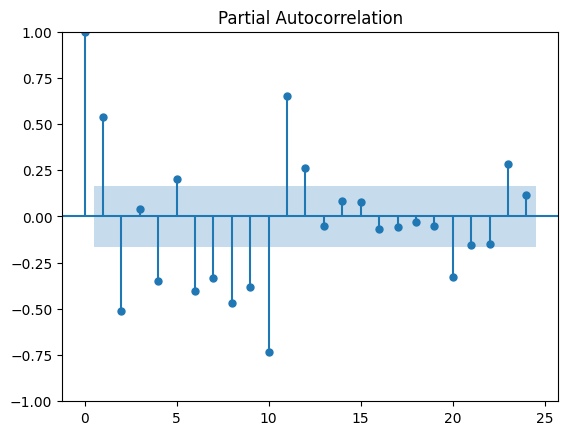

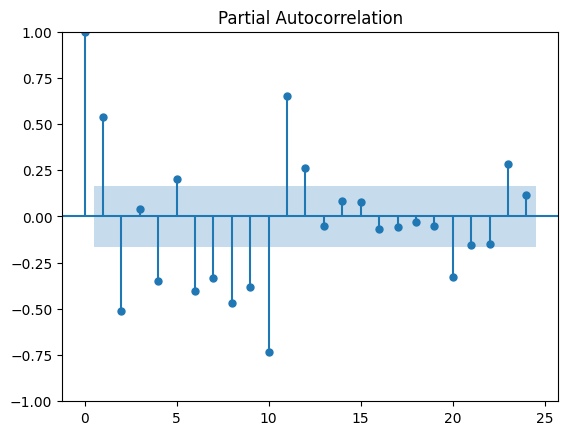

In [298]:
#PACF
smt.graphics.plot_pacf(ln_tp_diff2, lags = 24, method='ols')

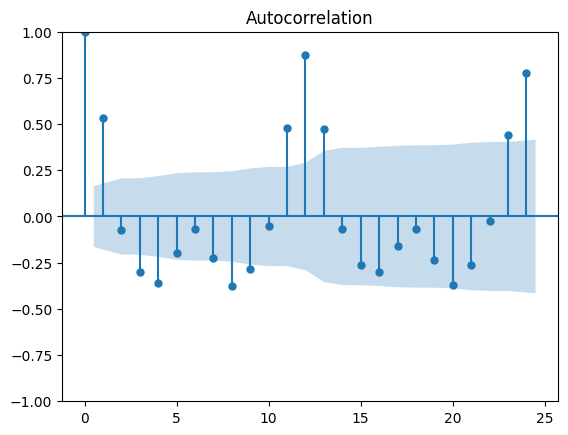

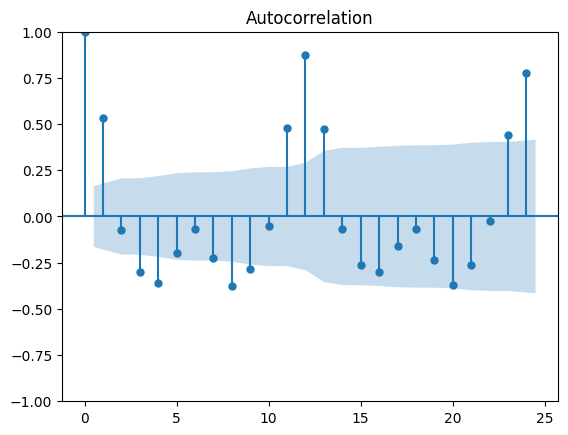

In [299]:
#ACF plot 
sm.graphics.tsa.plot_acf(ln_tp_diff2, lags=24)

In [306]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(train, order = (1,0,1),
                                 seasonal_order= (1,0,1,12),
                                             enforce_stationarity=False,
                                             enforce_invertibility=False).fit()

In [307]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  138
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 230.817
Date:                            Thu, 16 Apr 2026   AIC                           -451.633
Time:                                    10:54:13   BIC                           -437.532
Sample:                                01-01-1949   HQIC                          -445.905
                                     - 06-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9357      0.042     22.033      0.000       0.852       1.019
ma.L1         -0.3694      0.097   

In [308]:
f_cast = np.exp(model.forecast(12))

In [309]:
f_cast

1960-07-01    619.553237
1960-08-01    629.178007
1960-09-01    522.813926
1960-10-01    456.908181
1960-11-01    400.183379
1960-12-01    448.239068
1961-01-01    466.070993
1961-02-01    440.174877
1961-03-01    499.232886
1961-04-01    513.904521
1961-05-01    532.726709
1961-06-01    615.386617
Freq: MS, Name: predicted_mean, dtype: float64

In [310]:
import sys
import itertools
import warnings

def auto_arima(timeseries, regressors=None, p=range(0, 2), d=range(0, 2), q=range(0, 2),
              P=range(0, 2), D=range(0, 1), Q=range(0, 2)):

    # Generate all different combinations of p, d and q triplets
    pdq = list(itertools.product(p, d, q))

    # Generate all different combinations of seasonal p, q and q triplets
    seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(P, D, Q))]
    
    warnings.filterwarnings("ignore") # specify to ignore warning messages

    best_aic = np.inf
    best_pdq = None
    best_seasonal_pdq = None
    best_results = None
    
    for param in pdq:
        for param_seasonal in seasonal_pdq:

            try:
                temp_model = sm.tsa.statespace.SARIMAX(endog=timeseries,
                                                 exog=regressors,
                                                 order = param,
                                                 seasonal_order = param_seasonal,
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False)
                temp_results = temp_model.fit()

                print("SARIMAX{}x{}12 - AIC:{}".format(param, param_seasonal, temp_results.aic))
                
                if temp_results.aic < best_aic:
                    best_aic = temp_results.aic
                    best_pdq = param
                    best_seasonal_pdq = param_seasonal
                    best_results = temp_results
                
            except:
                #print("Unexpected error:", sys.exc_info()[0])
                continue
    print("Best SARIMAX{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))
    print(best_results.summary().tables[0])
    print(best_results.summary().tables[1])
    #return best_results

In [311]:
auto_arima(ln_tp_diff2)

SARIMAX(0, 0, 0)x(0, 0, 0, 12)12 - AIC:-104.57917074181938
SARIMAX(0, 0, 0)x(0, 0, 1, 12)12 - AIC:-189.30187934557773
SARIMAX(0, 0, 0)x(1, 0, 0, 12)12 - AIC:-394.5416659969181
SARIMAX(0, 0, 0)x(1, 0, 1, 12)12 - AIC:-421.2233617730114
SARIMAX(0, 0, 1)x(0, 0, 0, 12)12 - AIC:-219.55258133248856
SARIMAX(0, 0, 1)x(0, 0, 1, 12)12 - AIC:-284.6458479745447
SARIMAX(0, 0, 1)x(1, 0, 0, 12)12 - AIC:-428.915700752449
SARIMAX(0, 0, 1)x(1, 0, 1, 12)12 - AIC:-444.5295857547188
SARIMAX(0, 1, 0)x(0, 0, 0, 12)12 - AIC:-114.99586824443281
SARIMAX(0, 1, 0)x(0, 0, 1, 12)12 - AIC:-195.7408927988479
SARIMAX(0, 1, 0)x(1, 0, 0, 12)12 - AIC:-354.4047780096811
SARIMAX(0, 1, 0)x(1, 0, 1, 12)12 - AIC:-373.6036178843609
SARIMAX(0, 1, 1)x(0, 0, 0, 12)12 - AIC:-154.2569065962849
SARIMAX(0, 1, 1)x(0, 0, 1, 12)12 - AIC:-212.76952168867518
SARIMAX(0, 1, 1)x(1, 0, 0, 12)12 - AIC:-383.6559766423603
SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 - AIC:-405.42752545691656
SARIMAX(1, 0, 0)x(0, 0, 0, 12)12 - AIC:-151.67251639094812
SARIMAX(

In [312]:
# End of Notebook 